# 19th Feb 2026 - SAE Testing #1

Let's see if we can predict the single variable representations perfectly

In [2]:
import numpy as np
import jax.numpy as jnp
import jax.nn as jnn
import matplotlib.pyplot as plt
import optax
from jax import jit, random, grad, value_and_grad

0.0 0.71997774
ON-OFF
-0.051077424190206694


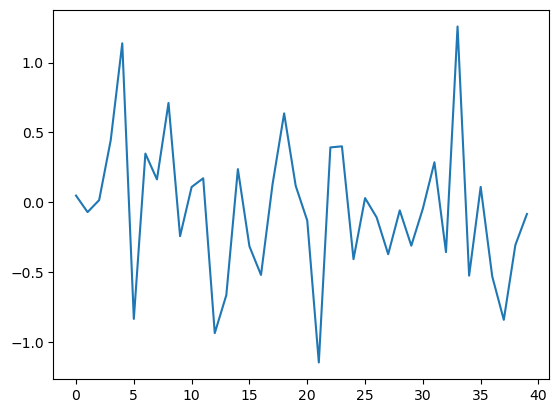

In [325]:
N = 10 # Number of neurons
D = 40 # Number of datapoints
lamb = 0.01 # Weight loss hyperparameter
random_seed = np.random.choice(10000)
act_reg = 3 # Which activity norm to use (1 = L1, 2 = L2, 3 = modified L1)
bias = 1

k = 0
x = jnn.relu(np.random.uniform(-k, 1, [1, D]))

S = np.mean(x == 0)
frac = np.mean(x)**2/np.mean(x**2)
print(S, frac)
if S < frac:
    print('ON-OFF')
else:
    print('Unit')

#x = x.at[:].set(0)
#x = x.at[0,0].set(1)
#x = x.at[0,1].set(-0.1)

x = np.random.normal(0, 0.5, [1, D])
x_extra = np.random.normal(4, 0.4, [1,10])
#x = np.hstack([x, x_extra])

D = x.shape[1]

plt.plot(x.T)
print(np.median(x))

(array([4., 2., 1., 7., 4., 3., 6., 5., 5., 3.]),
 array([-0.89115318, -0.72429127, -0.55742935, -0.39056743, -0.22370551,
        -0.05684359,  0.11001832,  0.27688024,  0.44374216,  0.61060408,
         0.777466  ]),
 <BarContainer object of 10 artists>)

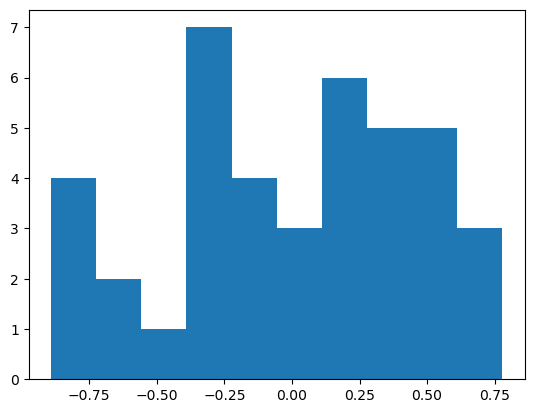

In [322]:
plt.hist(x.T)

Theoretical theta est in range -0.0004072364495686376 to 0.0007947228287830121


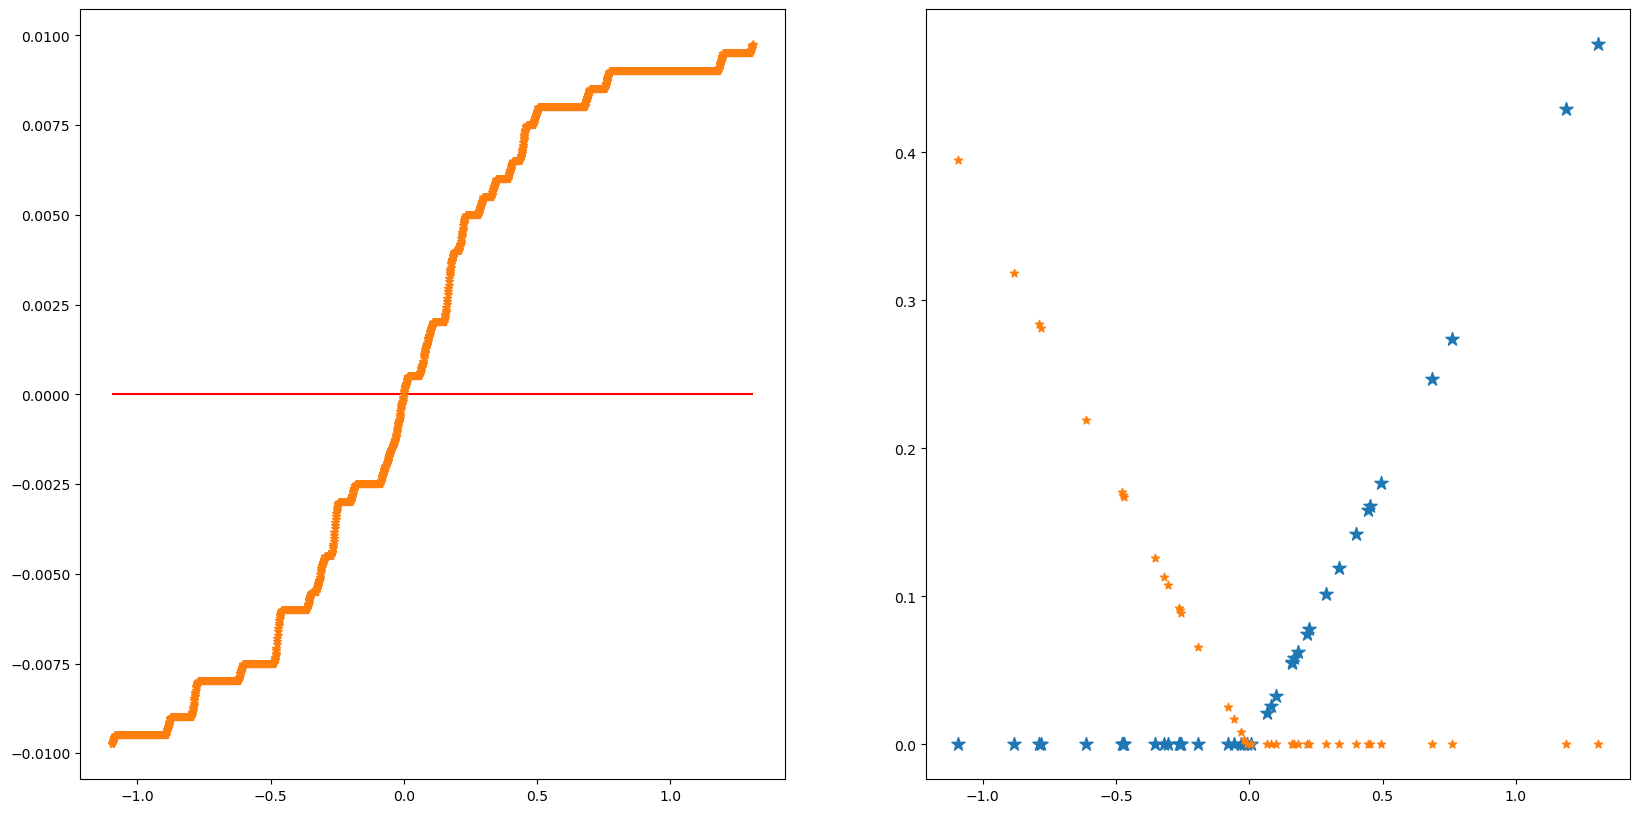

In [358]:
# Let's try and make the perfect theoretical prediction
num_thetas = 2000
x_dm = x - np.mean(x)

thetas = np.linspace(np.min(x_dm), np.max(x_dm), num_thetas)

theta_calc = np.zeros([num_thetas])

for theta_ind, theta in enumerate(thetas):
    pos_part = jnn.relu(x_dm - theta -lamb)
    neg_part = jnn.relu(-x_dm + theta - lamb)

    mu_pos_sq = np.sum(pos_part)
    mu_neg_sq = np.sum(neg_part)

    theta_calc[theta_ind] = (mu_neg_sq - mu_pos_sq)/D

plt.figure(figsize = (20,10))
plt.subplot(1,2,1)
plt.plot(thetas, thetas - theta_calc)
plt.plot(thetas, thetas - theta_calc, '*')
plt.hlines(0, np.min(x_dm), np.max(x_dm), 'r', zorder = -1)

theta_est_ind = np.argmin(np.abs(thetas - theta_calc))
if np.abs(thetas - theta_calc)[theta_est_ind+1] < np.abs(thetas - theta_calc)[theta_est_ind-1]:
    print(f'Theoretical theta est in range {thetas[theta_est_ind]} to {thetas[theta_est_ind+1]}')
else:
    print(f'Theoretical theta est in range {thetas[theta_est_ind-1]} to {thetas[theta_est_ind]}')

theta_choose = theta_calc[theta_est_ind]
mu_pos = np.sqrt(np.sum(jnn.relu(x_dm - theta_choose -lamb)))
mu_neg = np.sqrt(np.sum(jnn.relu(-x_dm + theta_choose -lamb)))

z_pos = 1/mu_pos*jnn.relu(x_dm - theta_choose -lamb)
z_neg = 1/mu_neg*jnn.relu(-x_dm + theta_choose -lamb)

plt.subplot(1,2,2)
plt.scatter(x_dm[0,:], z_pos, 100, marker = '*')
plt.scatter(x_dm[0,:], z_neg, marker = '*')

In [299]:
theta_lim = np.min(x_dm) + lamb
theta_derived = -np.mean(jnn.relu(x_dm - np.mean(x_dm) - 2*lamb))

if theta_lim > theta_derived:
    print('Single Neuron')
else:
    

IndentationError: expected an indented block after 'else' statement on line 6 (3574698977.py, line 7)

In [328]:
@jit
def stick_a_bias_on(g):
    g_bias = jnp.vstack([g, jnp.ones(g.shape[1])[None,:]])
    return g_bias

if bias:
    @jit
    def generate_R(g, outputs):
        mat0 = jnp.matmul(g, g.T)
        mat1 = jnp.matmul(g, outputs.T)
        mat2 = jnp.matmul(jnp.linalg.inv(mat0 + 0.01*jnp.eye(N+1)), mat1)
        return mat2

else:
    @jit
    def generate_R(g, outputs):
        mat0 = jnp.matmul(g, g.T)
        mat1 = jnp.matmul(g, outputs.T)
        mat2 = jnp.matmul(jnp.linalg.inv(mat0 + 0.01*jnp.eye(N)), mat1)
        return mat2
        
@jit
def loss_fit(g, R, outputs):
    preds = R.T@g
    return jnp.linalg.norm(outputs - preds)**2

if bias:
    @jit
    def loss_R(R):
        return jnp.sum(jnp.power(R[:N], 2))
else:
    @jit
    def loss_R(R):
        return jnp.sum(jnp.power(R, 2))
        
if act_reg == 2:
    @jit
    def loss_act(g):
        return jnp.sum(jnp.power(g, 2))
elif act_reg == 1:
    @jit
    def loss_act(g):
        return jnp.sum(jnp.abs(g))
elif act_reg == 3:
    @jit
    def loss_act(g):
        return np.sum(g.T@g)

@jit
def loss_pos(g):
    g_neg = (g - jnp.abs(g))/2
    L_pos = -jnp.sum(g_neg)
    return L_pos    

# Loss function parameters
mu_fit = 5
mu_G = lamb
mu_R = lamb
positivise = 1
if positivise:
    mu_pos = 0
else:
    mu_pos = 10000

# Add a cap?
to_cap = 0
if to_cap:
    mu_cap = 10
    cap = 0.3

@jit
def loss(params, outputs):
    if positivise:
        g_here = params['G'] - np.min(params['G'])
    else:
        g_here = params['G']
        
    if bias:
        g_use = stick_a_bias_on(g_here)
    else:
        g_use = g_here
        
    R = generate_R(g_use, outputs)
    if to_cap:
        return mu_fit*loss_fit(g_use, R, outputs) + mu_G*loss_act(g_here) + mu_R*loss_R(R) + mu_pos*loss_pos(g_here) + mu_cap*loss_pos(cap-g_here)
    else:
        return mu_fit*loss_fit(g_use, R, outputs) + mu_G*loss_act(g_here) + mu_R*loss_R(R) + mu_pos*loss_pos(g_here)

@jit
def update(params, outputs, opt_state):
    """ Compute the gradient for a batch and update the parameters """
    value, grads = value_and_grad(loss)(params, outputs)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, value

def measure_loss(params, outputs):
    if positivise:
        g_here = params['G'] - np.min(params['G'])
    else:
        g_here = params['G']
        
    if bias:
        g_use = stick_a_bias_on(g_here)
    else:
        g_use = g_here
        
    R = generate_R(g_use, outputs)

    l_fit = mu_fit*loss_fit(g_use, R, outputs)
    l_act = mu_G*loss_act(g_here)
    l_red = mu_R*loss_R(R)
    if to_cap:
        l_cap = mu_cap*loss_pos(cap-g_here)
        
    if positivise:
        if to_cap:
            l_tot = mu_fit*l_fit + mu_G*l_act + mu_R*l_red + mu_cap*l_cap
            print(f'Loss: {l_tot:.5f}, fit: {l_fit:.5f}, act: {l_act:.5f}, red: {l_red:.5f}, cap: {l_cap:.5f}')
        else:
            l_tot = mu_fit*l_fit + mu_G*l_act + mu_R*l_red
            print(f'Loss: {l_tot:.5f}, fit: {l_fit:.5f}, act: {l_act:.5f}, red: {l_red:.5f}')
    else:
        l_pos = loss_pos(g_here)
        l_tot = mu_fit*l_fit + mu_G*l_act + mu_R*l_red + mu_pos*l_pos
        print(f'Loss: {l_tot:.5f}, fit: {l_fit:.5f}, act: {l_act:.5f}, red: {l_red:.5f}, pos: {l_pos:.5f}')
        
# Simulation parameters
learning_rate = 1e-4
random_seed = np.random.choice(10000)

re_init = 1
if re_init:
    key = random.PRNGKey(random_seed)
    G = random.normal(key, (N, D))*0.001
    # Obtain the `opt_state` that contains statistics for the optimizer.
    params = {'G': G}
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)
print(loss(params, x))
min_loss = np.inf

51.11295


In [329]:
# Optimisation, run and re-run until it stops hitting new records
T = 100000000
print_iter = 100000

for t in range(T):
    params, opt_state, loss = update(params, x, opt_state)

    if t % print_iter == 0:
        measure_loss(params, x)
        min_this_step = 0

    if loss < min_loss:
        params_best = params
        min_loss = loss
        if min_this_step == 0:
            print(f'New min! {loss}')#, Theo: {act_loss_use + lamb*weight_loss_use:.5f}')
            min_this_step = 1

Loss: 254.97533, fit: 50.99502, act: 0.00148, red: 0.02154
New min! 51.11294937133789
Loss: 0.05742, fit: 0.01087, act: 0.16143, red: 0.14409
New min! 0.31603679060935974


KeyboardInterrupt: 

In [333]:
axs

array([[<AxesSubplot:>, <AxesSubplot:>,
        <AxesSubplot:title={'center':'Min Loss: 0.3160368'}>,
        <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

In [343]:
ax

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>], dtype=object)

[[<AxesSubplot:> <AxesSubplot:> <AxesSubplot:> <AxesSubplot:>
  <AxesSubplot:>]
 [<AxesSubplot:> <AxesSubplot:> <AxesSubplot:> <AxesSubplot:>
  <AxesSubplot:>]]


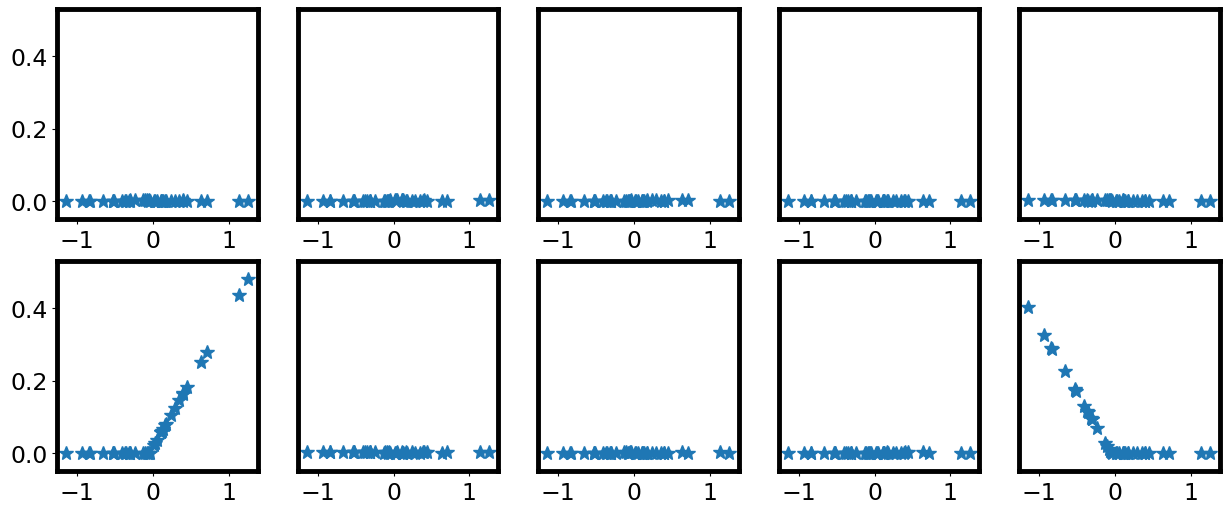

In [368]:
num_rows = 2
num_cols = int(np.ceil(N/num_rows))

if positivise:
    g_here = params_best['G'] - np.min(params_best['G'])
else:
    g_here = params_best['G']

fig, axs = plt.subplots(num_rows, num_cols, figsize = (15, num_rows*3))
print(axs)
for ax_ind, ax in enumerate(np.ndarray.flatten(axs)):
    ax.plot(x[0,:], g_here[ax_ind,:],'*', ms = 10)
    #plt.xticks([])
    ax.set_ylim([-0.05, 1.1*np.max(g_here)])
    
    if ax_ind % num_cols != 0:
        ax.set_yticks([])

    if neuron == np.floor(num_cols/2):
        axs[neuron].title(f'Min Loss: {min_loss:.7f}') 

for ax_ind, ax in enumerate(np.ndarray.flatten(axs)):
    #ax.set_ylim([-0.01, 0.55])    
    #ax.set_yticks([0, 0.5])
    #ax.set_xticks([-1.5, 1.5])
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set_linewidth(3.5)
    ax.tick_params(axis='both', labelsize=17)

In [360]:
active_neurons[0]

0

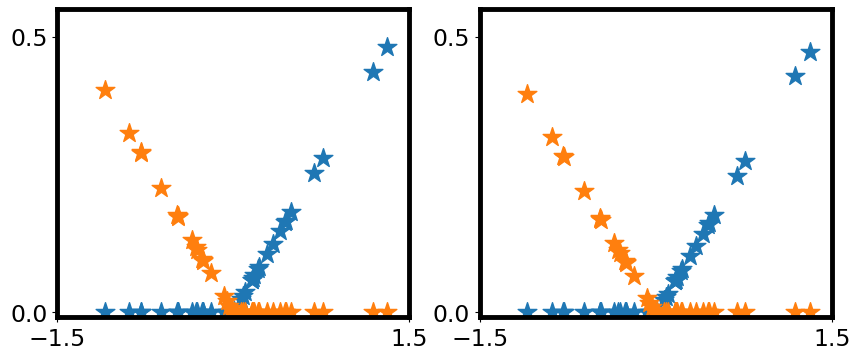

In [366]:
sig_activity_level = 0.005
significantly_active = g_here > sig_activity_level
active_neurons = np.where(np.sum(significantly_active, axis = 1) > 0)[0]

fig, axs = plt.subplots(1,2, figsize = (10,4))

plt.subplot(1,2,1)
plt.scatter(x_dm[0,:], g_here[active_neurons[0],:], 200, marker = '*')
plt.scatter(x_dm[0,:], g_here[active_neurons[1],:], 200, marker = '*')

plt.subplot(1,2,2)
plt.scatter(x_dm[0,:], z_pos, 200, marker = '*')
plt.scatter(x_dm[0,:], z_neg, 200, marker = '*')

for ax in axs:
    ax.set_ylim([-0.01, 0.55])    
    ax.set_yticks([0, 0.5])
    ax.set_xticks([-1.5, 1.5])
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set_linewidth(3.5)
    ax.tick_params(axis='both', labelsize=17)
#axs[0].set_ylabel('Neuron Activity', fontsize = 17)

In [365]:
active_neurons

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])